In [3]:
import os
import pandas as pd
import matplotlib.pyplot as plt
enrollPerTown = pd.read_csv('neighborhood_enrollment.csv')
#imports enrollment data into enrolPerTown
popPerZip = pd.read_excel('Pennsylvania_DemographicsByZipCode_sample.xlsx',sheet_name='2024AmericanCommunitySurvey', header=4)
#imports population and zip code data into popPerZip

#IMPORTANT - In order to run this code you MUST install or have installed openpyxl, this is due to one of the data sets being a xlxs file!


Main Task of The Data:
The goal of sorting through this dataset is to find the current enrollment in schools per capita. Their is two main datasets that are needed in order to achive this, that being the enrolment data of each town. As well as the population by town and zip code.

In [4]:
pureEnroll = (enrollPerTown.groupby('neighborhood')['total_students_enrolled'].sum().reset_index())
pureEnroll = pureEnroll[pureEnroll['total_students_enrolled'] > 0]

The code above is just there to combine the enrollment data across grades into just one row per town.

But the next main problem we have is that there is no way to connect the two datasets without converting the towns to zipcodes and then back. I feel that the best way to do this is just to add a matrix in the connects the towns to the zipcodes. Below is just a library that allows for us to achieve this.

In [5]:
neighToZip = {
        'Allegheny Center':   '15212',
    'Allentown':          '15210',
    'Arlington':          '15210',
    'Arlington Heights':  '15210',
    'Banksville':         '15216',
    'Bedford Dwellings':  '15219',
    'Beechview':          '15216',
    'Beltzhoover':        '15210',
    'Bluff':              '15219',
    'Bon Air':            '15226',
    'Brighton Heights':   '15212',
    'Bloomfield':         '15224',
    'Brookline':          '15226',
    'California-Kirkbride': '15212',
    'Carrick':            '15227',
    'Central Lawrenceville': '15201',
    'Central Northside':  '15212',
    'Chartiers City':     '15220',
    'Crafton Heights':    '15205',
    'Crawford-Roberts':   '15219',
    'Duquesne Heights':   '15211',
    'East Allegheny':     '15212',
    'East Carnegie':      '15106',
    'East Hills':         '15221',
    'East Liberty':       '15206',
    'Elliott':            '15205',
    'Fairywood':          '15205',
    'Fineview':           '15214',
    'Friendship':         '15224',
    'Garfield':           '15206',
    'Glen Hazel':         '15207',
    'Greenfield':         '15207',
    'Hays':               '15207',
    'Hazelwood':          '15207',
    'Highland Park':      '15206',
    'Homewood North':     '15208',
    'Homewood South':     '15208',
    'Homewood West':      '15208',
    'Knoxville':          '15210',
    'Larimer':            '15206',
    'Lincoln Place':      '15235',
    'Lincoln-Lemington-Belmar': '15206',
    'Lower Lawrenceville': '15201',
    'Manchester':         '15233',
    'Marshall-Shadeland': '15212',
    'Middle Hill':        '15219',
    'Morningside':        '15215',
    'Mount Oliver':       '15210',
    'Mount Washington':   '15211',
    'Mt. Oliver Borough': '15210',
    'New Homestead':      '15207',
    'Northview Heights':  '15212',
    'Oakwood':            '15205',
    'Overbrook':          '15210',
    'Perry North':        '15214',
    'Perry South':        '15209',
    'Point Breeze':       '15208',
    'Point Breeze North': '15206',
    'Polish Hill':        '15224',
    'Regent Square':      '15218',
    'Saint Clair':        '15210',
    'Shadyside':          '15232',
    'Sheraden':           '15204',
    'South Oakland':      '15213',
    'South Side Flats':   '15203',
    'South Side Slopes':  '15203',
    'Spring Garden':      '15212',
    'Spring Hill-City View': '15212',
    'Squirrel Hill North': '15217',
    'Squirrel Hill South': '15217',
    'Stanton Heights':    '15201',
    'Summer Hill':        '15237',
    'Swisshelm Park':     '15218',
    'Terrace Village':    '15219',
    'Troy Hill':          '15212',
    'Upper Hill':         '15219',
    'Upper Lawrenceville': '15201',
    'West End':           '15205',
    'West Oakland':       '15213',
    'Westwood':           '15205',
    'Wilkinsburg Borough': '15221',
    'Windgap':            '15204',
    'Bairdford' : '15006',
    'Bakerstown' : '15007',
    'Brackenridge' : '15014',
    'Bradfordwoods' : '15015',
    'Bridgeville' : '15017',
    'Buena Vista' : '15018',
    'Bunola' : '15020',
    'Cheswick' : '15024',
    'Floreffe' : '15025',
    'Jefferson Hills' : '15025',
    'Large' : '15025',
    'Clairton' : '15025',
    'Coulters' : '15028',
    'Creighton' : '15030',
    'Cuddy' : '15031',
    'Curtisville' : '15032',
    'Dravosburg' : '15034',
    'East Mc Keesport' : '15035',
    'Elizabeth' : '15037',
    'Gibsonia' : '15044',
    'Glassport' : '15045',
    'Glenwillard' : '15046',
    'Crescent' : '15046',
    'Greenock' : '15047',
    'Harwick' : '15049',
    'Indianola' : '15051',
    'Leetsdale' : '15056',
    'Morgan' : '15064',
    'Natrona' : '15065',
    'Noblestown' : '15071',
    'Oakdale' : '15071',
    'Rural Ridge' : '15075',
    'Russellton' : '15076',
    'Sturgeon' : '15082',
    'Tarentum' : '15084',
    'Warrendale' : '15086',
    'West Elizabeth' : '15088',
    'Wexford' : '15090',
    'Wildwood' : '15091',
    'Bulk Mail Center' : '15095',
    'Warrendale' : '15095',
    'Allison Park' : '15101',
    'Bethel Park' : '15102',
    'Braddock' : '15104',
    'Rankin' : '15104',
    'Carnegie' : '15106',
    'Heidelberg' : '15106',
    'Moon Township' : '15108',
    'Coraopolis' : '15108',
    'Duquesne' : '15110',
    'East Pittsburgh' : '15112',
    'Glenshaw' : '15116',
    'Homestead' : '15120',
    'Munhall' : '15120',
    'West Homestead' : '15120',
    'Whitaker' : '15120',
    'Pittsburgh' : '15122',
    'West Mifflin' : '15122',
    'West Mifflin' : '15123',
    'Imperial' : '15126',
    'Ingomar' : '15127',
    'Library' : '15129',
    'South Park' : '15129',
    'McKeesport' : '15130',
    'McKeesport' : '15131',
    'White Oak' : '15131',
    'McKeesport' : '15132',
    'McKeesport' : '15133',
    'McKeesport' : '15134',
    'Boston' : '15135',
    'McKeesport' : '15135',
    'McKees Rocks' : '15136',
    'North Versailles' : '15137',
    'Oakmont' : '15139',
    'Monroeville' : '15140',
    'Pitcairn' : '15140',
    'Presto' : '15142',
    'Edgeworth' : '15143',
    'Sewickley' : '15143',
    'Springdale' : '15144',
    'Turtle Creek' : '15145',
    'Monroeville' : '15146',
    'Verona' : '15147',
    'Wall' : '15148',
    'Wilmerding' : '15148',
    'Arsenal' : '15201',
    'Pittsburgh' : '15201',
    'Bellvue' : '15202',
    'Avalon' : '15202',
    'Bellevue' : '15202',
    'Ben Avon' : '15202',
    'Emsworth' : '15202',
    'Pittsburgh' : '15202',
    'Carson' : '15203',
    'Pittsburgh' : '15203',
    'Corliss' : '15204',
    'Pittsburgh' : '15204',
    'Crafton' : '15205',
    'Pittsburgh' : '15205',
    'East Liberty' : '15206',
    'Pittsburgh' : '15206',
    'Hazelwood' : '15207',
    'Pittsburgh' : '15207',
    'Homewood' : '15208',
    'Pittsburgh' : '15208',
    'Millvale' : '15209',
    'Pittsburgh' : '15209',
    'Mt Oliver' : '15210',
    'Mount Oliver' : '15210',
    'Pittsburgh' : '15210',
    'Mount Washington' : '15211',
    'Mt Washington' : '15211',
    'Pittsburgh' : '15211',
    'Allegheny' : '15212',
    'Pittsburgh' : '15212',
    'Oakland' : '15213',
    'Pittsburgh' : '15213',
    'Observatory' : '15214',
    'Pittsburgh' : '15214',
    'Aspinwall' : '15215',
    'Pittsburgh' : '15215',
    'Sharpsburg' : '15215',
    'South Hills' : '15216',
    'Pittsburgh' : '15216',
    'Squirrel Hill' : '15217',
    'Pittsburgh' : '15217',
    'Pittsburgh' : '15218',
    'Swissvale' : '15218',
    'Pittsburgh' : '15219',
    'Wabash' : '15220',
    'Pittsburgh' : '15220',
    'Pittsburgh' : '15221',
    'Wilkinsburg' : '15221',
    'Pittsburgh' : '15222',
    'Etna' : '15223',
    'Pittsburgh' : '15223',
    'Bloomfield' : '15224',
    'Pittsburgh' : '15224',
    'Neville Island' : '15225',
    'Brookline' : '15226',
    'Pittsburgh' : '15226',
    'Brentwood' : '15227',
    'Pittsburgh' : '15227',
    'Mount Lebanon' : '15228',
    'Pittsburgh' : '15228',
    'Pittsburgh' : '15229',
    'West View' : '15229',
    'Pittsburgh' : '15230',
    'Pittsburgh' : '15231',
    'Shadyside' : '15232',
    'Pittsburgh' : '15232',
    'Kilbuck' : '15233',
    'Pittsburgh' : '15233',
    'Castle Shannon' : '15234',
    'Pittsburgh' : '15234',
    'Penn Hills' : '15235',
    'Pittsburgh' : '15235',
    'Caste Village' : '15236',
    'Pittsburgh' : '15236',
    'Pleasant Hills' : '15236',
    'West Mifflin' : '15236',
    'Mcknight' : '15237',
    'Pittsburgh' : '15237',
    'Blawnox' : '15238',
    'Pittsburgh' : '15238',
    'Pittsburgh' : '15239',
    'Plum' : '15239',
    'Pittsburgh' : '15240',
    'Upper Saint Clair' : '15241',
    'Pittsburgh' : '15241',
    'Greentree' : '15242',
    'Pittsburgh' : '15242',
    'Cedarhurst' : '15243',
    'Pittsburgh' : '15243',
    'Montour' : '15244',
    'Pittsburgh' : '15244',
    'Pittsburgh' : '15250',
    'Pittsburgh' : '15251',
    'Pittsburgh' : '15260',
    'Pittsburgh' : '15264',
    'Pittsburgh' : '15272',
    'Pittsburgh' : '15274',
    'Pittsburgh' : '15275',
    'Pittsburgh' : '15276',
    'Pittsburgh' : '15290',
    'Pittsburgh' : '15295',
}

pureEnroll['zip_code'] = pureEnroll['neighborhood'].map(neighToZip)

For just zipcodes in and around pittsburgh creating a database of zipcodes within the program itself does work, but for a larger dataset it would be preferable to input the dataset as a csv. What this database is doing is connecting the town with it's respectable zipcode, in order to allow for us to work with the other table.


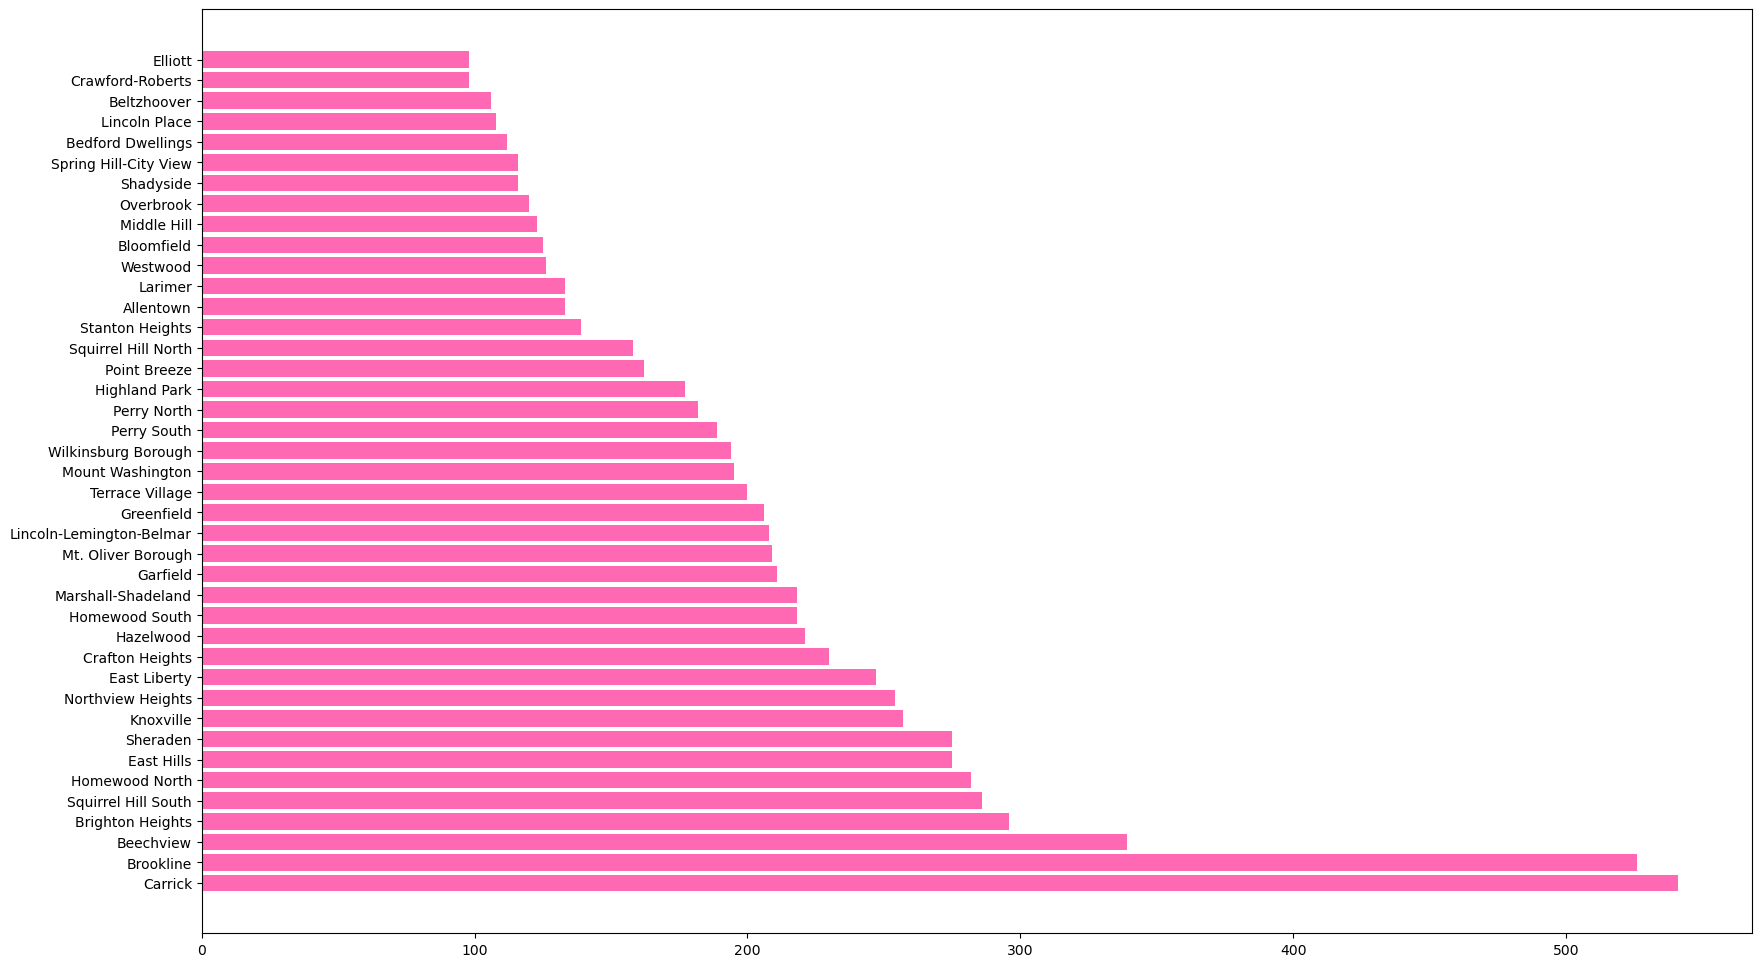

In [6]:
topGroup1 = enrollPerTown.nlargest(90, 'total_students_enrolled')
fig, ax = plt.subplots(figsize=(20, 12))
ax.barh(topGroup1['neighborhood'], topGroup1['total_students_enrolled'], color='#FF69B4')
plt.tight_layout
plt.show()

The chart I created above goes through and sorts through all of the data by enrollment by town, that is close to what we need but not exactly, as this chart fails to account for the differences in population between the different towns. So well Carrick does have the largest enrollments, this does not mean that it has the largest percentage of students enrolled, just largest total number of students.

In [7]:
popData = popPerZip[['name', 'population']].copy()
popData.columns = ['zip_code', 'population']
popData['zip_code'] = popData['zip_code'].astype(str)

What the box does above is take the data from the the Pennsylvania Demographics spreadsheet and modify it to work with the data from the neighborhood enrollment spread sheet.

In [8]:
merged = pureEnroll.merge(popData, on='zip_code', how='left')
merged['studentsCap'] = (merged['total_students_enrolled'] / merged['population'] * 1000)

These lines of code are working to sort through the data and output it in a form that can be used to create a graph, alowing us to compare ad contrast the data

In [10]:
merged = merged.sort_values('total_students_enrolled', ascending=False)
print(merged[['neighborhood', 'total_students_enrolled', 'zip_code', 'population', 'studentsCap']])

           neighborhood  total_students_enrolled zip_code  population  \
14              Carrick                   1276.0    15227       28460   
12            Brookline                   1169.0    15226       13999   
6             Beechview                    794.0    15216       21471   
62             Sheraden                    694.0    15204        8467   
69  Squirrel Hill South                    679.0    15217       25795   
..                  ...                      ...      ...         ...   
3     Arlington Heights                     21.0    15210       25227   
77             West End                     17.0    15205       24060   
17       Chartiers City                     15.0    15220       17644   
60          Saint Clair                     13.0    15210       25227   
22        East Carnegie                     12.0    15106       19244   

    studentsCap  
14    44.834856  
12    83.505965  
6     36.980113  
62    81.965277  
69    26.322931  
..          ...

Above is the data set after being merged together and output into the text form you see above.

The code you see below is there to take the data and form a graphy using matplotlib. It goes through and determines how many towns we want to display and in what order we want to display them, in this case it's by which towns have the highest enrollment per capita. IT also goes through formating like axis titles and the colors of the bars.

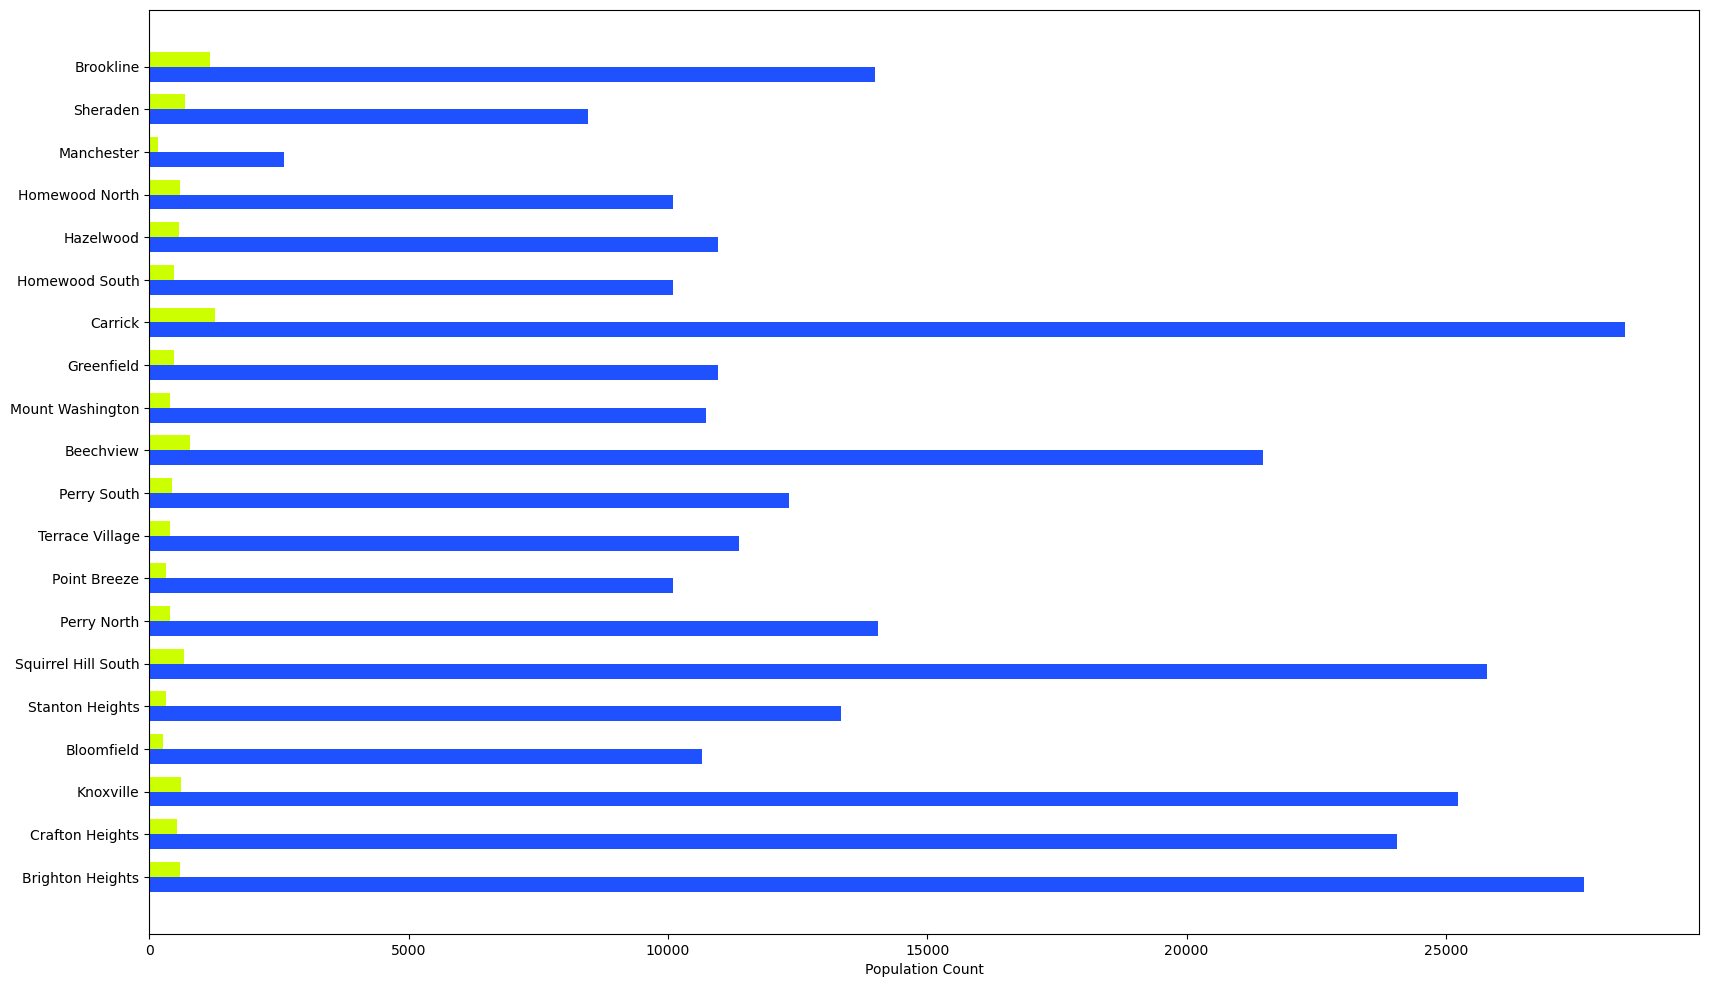

<function matplotlib.pyplot.tight_layout(*, pad: 'float' = 1.08, h_pad: 'float | None' = None, w_pad: 'float | None' = None, rect: 'tuple[float, float, float, float] | None' = None) -> 'None'>

In [12]:
topGroup2 = merged.nlargest(20, 'studentsCap').sort_values('studentsCap')
fig, ax = plt.subplots(figsize=(20, 12))

HADD =range(len(topGroup2))
height = .35
ax.barh([y + height/2 for y in HADD], topGroup2['total_students_enrolled'], height, color='#CCFF00', label='Students currently enrolled')
ax.barh([y - height/2 for y in HADD], topGroup2['population'], height, color='#1F51FF', label = 'Population')
ax.set_xlabel('Population Count')

ax.legend
ax.set_yticks(HADD)
ax.set_yticklabels(topGroup2['neighborhood'])
plt.show()
plt.tight_layout

The chart above compares population vs enrollment. This gives you an idea of how much of the population is currently enrolled in schools town to town. The towns currently on display are the top 20 when it comes to having the highest enrollment per-capita. With this data we can conclude that the town that has the highest enrollment per capita is Brookline, with Sheraden and Manchester trailing behind. So by this metric we can declare Brookline as the winner!